In [1]:
from itertools import permutations
from collections import defaultdict
import random
import matplotlib.pyplot as plt

from visualize_cards import Card
from helpers import print_cards_in_row

In [2]:
every_possible_card = [] #81 cards, not too much RAM
for a in range(3):
    for b in range(3):
        for c in range(3):
            for d in range(3):
                every_possible_card.append((a, b, c, d))

actual_sets = []
for a, b, c in permutations(every_possible_card, 3):
    is_set = True
    for idx in range(4):
        if (a[idx] + b[idx] + c[idx]) % 3  == 0:
            continue
        else:
            is_set = False
            break
    if is_set:
        actual_sets.append((a, b, c))
print(f'All actual sets: {len(actual_sets)}')

All actual sets: 6480


In [3]:
def count_monoattr(a, b, c):
    count = 0
    for idx in range(4):
        if len({a[idx], b[idx], c[idx]}) == 1:
            count += 1
    return count

In [4]:
#spot check
for _ in range(5):
    cards = random.choice(actual_sets)
    cards_obj = list(map(Card, cards))
    print_cards_in_row(cards_obj)
    print(f'monoattributes: {count_monoattr(*cards)}')

┌───┐ ┌───┐ ┌───┐ 
│╔☐╝│ │   │ │(■)│ 
│╔☐╝│ │<▥>│ │   │ 
│╔☐╝│ │   │ │(■)│ 
└───┘ └───┘ └───┘ 
monoattributes: 0
┌───┐ ┌───┐ ┌───┐ 
│╔■╝│ │(■)│ │   │ 
│   │ │(■)│ │<■>│ 
│╔■╝│ │(■)│ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│(▥)│ │╔▥╝│ │   │ 
│(▥)│ │   │ │<▥>│ 
│(▥)│ │╔▥╝│ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│   │ │╔☐╝│ │<▥>│ 
│(■)│ │   │ │<▥>│ 
│   │ │╔☐╝│ │<▥>│ 
└───┘ └───┘ └───┘ 
monoattributes: 0
┌───┐ ┌───┐ ┌───┐ 
│<■>│ │<☐>│ │<▥>│ 
│   │ │   │ │   │ 
│<■>│ │<☐>│ │<▥>│ 
└───┘ └───┘ └───┘ 
monoattributes: 2


In [ ]:
attr_count = defaultdict(int)
for cards in actual_sets:
    attr_count[count_monoattr(*cards)] += 1
print(attr_count)
print({k: f'{(100*v/len(actual_sets))}%' for k, v in attr_count.items()})

defaultdict(<class 'int'>, {3: 648, 2: 1944, 1: 2592, 0: 1296})
{3: '10.0%', 2: '30.0%', 1: '40.0%', 0: '20.0%'}


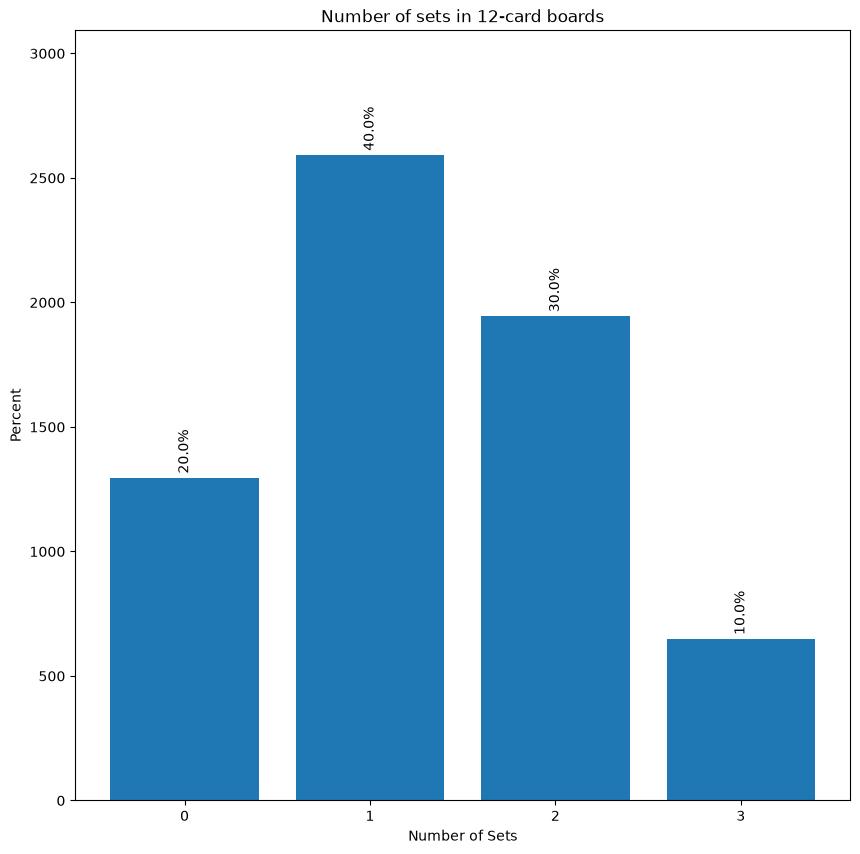

In [11]:
labels = [k for k, v in attr_count.items()]
sizes = [v for k, v in attr_count.items()]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.bar(labels, sizes)

# labels on each bar
ax.bar_label(bars, labels=[f"{(100 * v)/sum(sizes)}%" for v in sizes], padding=3, rotation=90)
ax.set_ylim(0, max(sizes)+500)
ax.set_xticks(labels)
ax.set_title("Number of sets in 12-card boards")
ax.set_xlabel("Number of Sets")
ax.set_ylabel("Percent")

plt.show()